Local Navigation + Motion Control 

Steps: 
1- Read Thymio's prox sensors 
2- Update a local occupancy grid around the robot
3- Take the global path (array of (X,Y) points in the world frame)
4- Local Navigation: 
    - picks a look agad point on that path 
    - checks if straight line to it is free in local grid
    - if blocked, computes a potential-field direction (path attraction +obstacle repulsion)
    - outputs a virtual goal in world coordinates 
4- Motion Control (Astoldi / go to goal) tracks that virtual goal 

In [1]:
import os
import sys
import math
from statistics import mean
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from local_occupancy import sensor_measurements, sensor_distances
from local_occupancy import thymio_coords, sensor_pos_from_center, sensor_angles
import numpy as np
from src.pose_estimation.extended_kalman_filter import ExtendedKalmanFilter
from src.pose_estimation.differential_drive_system import DifferentialDriveSystem
# Progress bar for loops visualization
from tqdm import tqdm
# Plotting
import matplotlib.pyplot as plt
from src.utils.plot_pose_estimation import *
%matplotlib inline

In [2]:
def variable_info(variable):
    """
    Provided a variable, prints the type and content of the variable
    """
    print("This variable is a {}".format(type(variable)))
    if type(variable) == np.ndarray:
        print("\n\nThe shape is {}".format(variable.shape))
    print("\n\nThe data contained in the variable is : ")
    print(variable)
    print("\n\nThe elements that can be accessed in the variable are :\n")
    print(dir(variable))
    
variable_info(np.array([1]))

This variable is a <class 'numpy.ndarray'>


The shape is (1,)


The data contained in the variable is : 
[1]


The elements that can be accessed in the variable are :

['T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dir__', '__divmod__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imatmul__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '_

In [3]:
## Interpolation from sensor values to distances in cm
def sensor_val_to_cm_dist(val):
    """
    Returns the distance corresponding to the sensor value based 
    on the sensor characteristics
    :param val: the sensor value that you want to convert to a distance
    :return: corresponding distance in cm
    """
# Some sensors report 0 when nothing is detected (out of range).
    # Treat that as "infinite" distance instead of trying to interpolate.
    if val == 0:
        return np.inf

    # Build a 1D interpolation function from calibration data.
    # interp1d will linearly interpolate y for any x inside the data range.
    # NOTE: By default, it raises a ValueError for x outside the range.
    # If you want extrapolation, use: interp1d(..., fill_value="extrapolate").
    f = interp1d(sensor_measurements, sensor_distances)

    # Evaluate the interpolation at the requested sensor value.
    # .item() returns a plain Python float from the 0-D NumPy result.
    return f(val).item()


# Example: verify the interpolation at a known calibration point.
# If sensor_measurements includes 4996 paired with ~2.19 cm,
# this should return a value close to 2.19.
sensor_val_to_cm_dist(4996)

1.0

In [4]:

# Raw Thymio prox -> obstacle positions around robot (cm)
# ------------------------------------------------------------

def obstacles_pos_from_sensor_vals(sensor_vals):
    """
    Convert Thymio's horizontal proximity values to obstacle positions
    in the ROBOT frame, in centimeters.

    Robot frame (matching course plots):
      - x = sideways (left +, right -)
      - y = forward  (in front of Thymio +)

    Assumes:
      - sensor_val_to_cm_dist(val)
      - sensor_angles          (angle of each sensor wrt forward)
      - sensor_pos_from_center (position of each sensor on Thymio)
    """
    # 1) raw value -> distance in cm (np.inf if nothing detected)
    dists_cm = [sensor_val_to_cm_dist(v) for v in sensor_vals]

    # 2) project along sensor angle (robot frame)
    dx = [d * math.cos(a) for d, a in zip(dists_cm, sensor_angles)]
    dy = [d * math.sin(a) for d, a in zip(dists_cm, sensor_angles)]

    # 3) shift from sensor head to robot center
    obstacles = []
    for (sx, sy), ddx, ddy in zip(sensor_pos_from_center, dx, dy):
        # sx, sy in cm; ddx, ddy in cm
        obstacles.append([sx + ddx, sy + ddy])

    return np.array(obstacles, dtype=float)  # shape (Nsensors, 2), in cm


In [5]:
# ------------------------------------------------------------
# local occupancy grid around Thymio (in meters)
# left + right - front + back -
# ------------------------------------------------------------

class LocalOccupancyGrid:
    """
    Robot-centred occupancy grid.

    - x axis: sideways (left +, right -)
    - y axis: forward (front +, back -)
    - Units inside: meters
    """

    def __init__(self,
                 size_m=0.15,        # grid side [m] 0.6 x 0.6 m (60cm x 60cm)
                 resolution_m=0.001, # cell size [m] 2cmx2cm
                 hit_inc=0.1,       # increment per hit
                 decay=0.98):       # to forget the obstacles over time 
        self.size_m     = size_m
        self.resolution = resolution_m
        self.hit_inc    = hit_inc
        self.decay      = decay

        self.half_size  = size_m / 2.0  #how far the gird extends from the center   
        self.n_cells    = int(size_m / resolution_m) #30 x30 matrix cells 
        self.grid       = np.zeros((self.n_cells, self.n_cells), dtype=float) #Occupancy grid

    # ---- coord <-> cell index ----

    def _point_to_index(self, x_m, y_m): 
        """
        Robot-frame point [m] -> (iy, ix) index.
        x_m: sideways, y_m: forward.
        """
        if abs(x_m) > self.half_size or abs(y_m) > self.half_size:
            return None # outside grid

        ix = int((x_m + self.half_size) / self.resolution)  #column index
        iy = int((y_m + self.half_size) / self.resolution) #row index

        ix = min(max(ix, 0), self.n_cells - 1) #safety clamp in case of rounding errors 
        iy = min(max(iy, 0), self.n_cells - 1)
        return iy, ix  #row, column

    def _index_to_point(self, iy, ix): #getting point from robot frame from cell index 
        """
        Cell index -> robot-frame point [m] at cell center.
        """
        x_m = (ix + 0.5) * self.resolution - self.half_size
        y_m = (iy + 0.5) * self.resolution - self.half_size
        return x_m, y_m

    # ---- main update from prox sensors ----

    def update_from_sensor_vals(self, sensor_vals):
        """
        Update grid from Thymio horizontal proximity sensor readings.
        """
        # Forget old stuff a bit
        self.grid *= self.decay 

        # obstacles around robot in cm
        obs_cm = obstacles_pos_from_sensor_vals(sensor_vals)

        for ox_cm, oy_cm in obs_cm:
            if not np.isfinite(ox_cm) or not np.isfinite(oy_cm):
                continue

            # cm -> m
            x_m = ox_cm / 100.0
            y_m = oy_cm / 100.0

            idx = self._point_to_index(x_m, y_m)
            if idx is None:
                continue

            iy, ix = idx
            self.grid[iy, ix] = min(1.0, self.grid[iy, ix] + self.hit_inc)


In [6]:
# ------------------------------------------------------------
#  local navigation config (tunable parameters)
# ------------------------------------------------------------

class LocalNavConfig:
    def __init__(self,
                 lookahead_dist_m=0.15,
                 max_lookahead_points=15,
                 occ_threshold=0.5,
                 rep_influence_radius=0.13,
                 k_att=1.0,
                 k_rep=0.6,
                 virt_goal_dist_m=0.10):
        """
        lookahead_dist_m      : how far along path to look ahead
        max_lookahead_points  : max indices to move ahead in path array
        occ_threshold         : cell value above this considered 'occupied'
        rep_influence_radius  : [m] radius where obstacles repel
        k_att                 : gain on attraction to path
        k_rep                 : gain on obstacle repulsion
        virt_goal_dist_m      : [m] distance of virtual goal in front of robot
        """
        self.lookahead_dist_m     = lookahead_dist_m
        self.max_lookahead_points = max_lookahead_points
        self.occ_threshold        = occ_threshold
        self.rep_influence_radius = rep_influence_radius
        self.k_att                = k_att
        self.k_rep                = k_rep
        self.virt_goal_dist_m     = virt_goal_dist_m


In [7]:
# ------------------------------------------------------------
# local navigation on top of grid + global path
# ------------------------------------------------------------

class LocalNavigator:
    """
    Takes:
      - pose [x, y, theta] in WORLD frame
      - global path (N x 2) in WORLD frame
      - LocalOccupancyGrid (around robot)

    Returns:
      - virtual goal [xg, yg] in WORLD frame
    """

    def __init__(self, grid: LocalOccupancyGrid, cfg: LocalNavConfig):
        self.grid     = grid
        self.cfg      = cfg
        self.path_idx = 0  # progress along global path

    # ---------- 4.1 World <-> Robot transforms ----------

    @staticmethod
    def world_to_robot(pose, point_world):
        """
        WORLD -> ROBOT frame.

        pose        = [x_r, y_r, theta_r] robot pose in thr world frame 
        point_world = [x_w, y_w] point in world frame 

        Robot:
          x_robot = left  (+)
          y_robot = fwd   (+)
        """
        x_r, y_r, theta = pose
        px, py = point_world

        dx = px - x_r #moving origin to robot 
        dy = py - y_r

        c = math.cos(theta)
        s = math.sin(theta)

        y_forward =  c*dx + s*dy #reorienting axes into robot axes
        x_left    = -s*dx + c*dy

        return np.array([x_left, y_forward], dtype=float)

    @staticmethod
    def robot_to_world(pose, point_robot):
        """
        ROBOT -> WORLD frame.

        pose        = [x_r, y_r, theta_r]
        point_robot = [x_left, y_forward]
        """
        x_r, y_r, theta = pose
        x_left, y_forward = point_robot

        c = math.cos(theta)
        s = math.sin(theta)

        dx_w = -s*x_left + c*y_forward
        dy_w =  c*x_left + s*y_forward

        return np.array([x_r + dx_w, y_r + dy_w], dtype=float)

    # ---------- 4.2 Find look-ahead point on path ----------

    def _find_lookahead_point(self, pose, path):
        """
        Returns (lookahead_point_world, closest_idx)
        """
        x, y, theta = pose # robot pose in world frame
        if path is None or path.shape[0] == 0:
            return None, None 

        start_idx = self.path_idx # continue from last progress
        end_idx   = min(path.shape[0], start_idx + self.cfg.max_lookahead_points) # furthest lookahead index
        segment   = path[start_idx:end_idx] #points with indices 
        dists2    = (segment[:, 0] - x)**2 + (segment[:, 1] - y)**2 # squared distances to robot
        k_local   = int(np.argmin(dists2)) #find closest point in segment
        k_global  = start_idx + k_local # locating robot approximately on full path
        
        # Update progress to guarantee we dont go backwards
        self.path_idx = k_global

        # Move forward along path until lookahead_dist is reached
        target_idx = k_global
        accum = 0.0 #how much distance we have accumulated along the path
        while (target_idx + 1 < path.shape[0] and # making sure we dont go out of bounds
               accum < self.cfg.lookahead_dist_m and # distance not yet reached
            target_idx - k_global < self.cfg.max_lookahead_points): # max lookahead points
            p0 = path[target_idx] #current point
            p1 = path[target_idx + 1] #next point on the path 
            step = float(np.linalg.norm(p1 - p0)) # distance between current and next point
            accum += step # accumulate distance
            target_idx += 1 # move to next point
        #target_idx is the index of selected lookahead point 
        LA_point = path[target_idx] # lookahead point in world frame
        return LA_point, k_global 

    # ---------- 4.3 Corridor check to LA ----------

    def _corridor_free_to_LA(self, p_LA_robot):
        """
        Straight line from (0,0) to p_LA_robot in ROBOT frame.
        Return True if no occupied cells on that line.
        """
        # If LA is behind or exactly at us, consider blocked
        if p_LA_robot[1] <= 0.0:
            return False

        n_samples = 10
        for i in range(1, n_samples + 1):
            alpha = i / n_samples
            pt = alpha * p_LA_robot  # [x_left, y_forward] in robot frame
            x_m, y_m = float(pt[0]), float(pt[1])

            idx = self.grid._point_to_index(x_m, y_m)
            if idx is None:
                continue

            iy, ix = idx
            if self.grid.grid[iy, ix] > self.cfg.occ_threshold:
                return False

        return True

    # ---------- 4.4 Repulsive vector from occupancy ----------

    def _repulsive_vector(self):
        """
        Compute repulsive force in ROBOT frame [x_left, y_forward].
        """
        F_rep = np.zeros(2, dtype=float)
        R = self.cfg.rep_influence_radius
        eps = 1e-3

        occ_idxs = np.argwhere(self.grid.grid > self.cfg.occ_threshold)

        for iy, ix in occ_idxs:
            x_m, y_m = self.grid._index_to_point(iy, ix)
            d = math.sqrt(x_m*x_m + y_m*y_m)

            if d < eps or d > R:
                continue

            # Direction from obstacle -> robot
            dir_vec = np.array([-x_m / d, -y_m / d])
            # Magnitude stronger when closer, zero at R
            mag = self.cfg.k_rep * (1.0 / d - 1.0 / R)

            F_rep += mag * dir_vec

        return F_rep

    # ---------- 4.5 MAIN: compute virtual goal ----------

    def compute_virtual_goal(self, pose, path):
        """
        pose : [x, y, theta] in WORLD frame
        path : (N, 2) array in WORLD frame

        Returns: [xg, yg] in WORLD frame or None.
        """
        if path is None or path.shape[0] == 0:
            return None

        # 1) Choose look-ahead on path
        p_LA_world, _ = self._find_lookahead_point(pose, path)
        if p_LA_world is None:
            return None

        # 2) Express LA in ROBOT frame
        p_LA_robot = self.world_to_robot(pose, p_LA_world)

        # 3) If straight path to LA is free, use LA directly
        if self._corridor_free_to_LA(p_LA_robot):
            return p_LA_world.copy()

        # 4) Else: compute potential-field direction

        # Attractive towards LA
        F_att = p_LA_robot.astype(float)
        norm_att = np.linalg.norm(F_att)
        if norm_att > 1e-6:
            F_att = (self.cfg.k_att / norm_att) * F_att

        # Repulsive from obstacles
        F_rep = self._repulsive_vector()

        F_tot = F_att + F_rep
        norm_tot = np.linalg.norm(F_tot)
        if norm_tot < 1e-6:
            # fallback: just forward
            F_tot = np.array([0.0, 1.0], dtype=float)
            norm_tot = 1.0

        dir_robot = F_tot / norm_tot  # unit vector in robot frame

        # Place virtual goal some distance ahead in that direction
        virt_robot = self.cfg.virt_goal_dist_m * dir_robot

        # 5) Convert back to WORLD frame
        virt_world = self.robot_to_world(pose, virt_robot)
        return virt_world


In [8]:
import math
import numpy as np
from dataclasses import dataclass

def wrap_to_pi(angle):
    return (angle + math.pi) % (2.0 * math.pi) - math.pi

@dataclass
class GoToGoalGains:
    Kv: float = 3.0      # forward gain
    Komega: float = 8.0  # turning gain
    v_max: float = 0.12  # [m/s] max forward speed
    w_max: float = 4.0   # [rad/s] max angular speed

@dataclass
class ThymioKinematics:
    wheel_radius: float = 0.022   # ~2.2 cm
    half_axle: float   = 0.0475   # half distance between wheels
    motor_gain: float  = 10.0     # rad/s -> motor units
    motor_max: int     = 300      # saturation of Thymio motor command

class GoToGoalController:
    """
    Simple go-to-goal controller for a differential-drive robot.

    Input:
      - pose = [x, y, theta] in WORLD frame
      - goal = [xg, yg] in WORLD frame

    Output:
      - left, right motor commands (integers)
    """

    def __init__(self,
                 gains: GoToGoalGains = GoToGoalGains(),
                 kin: ThymioKinematics = ThymioKinematics()):
        self.g = gains
        self.kin = kin

    def compute_unicycle_cmd(self, pose, goal_xy):
        """
        Compute (v, omega) to go from pose -> goal_xy.
        pose    : [x, y, theta] in WORLD frame
        goal_xy : [xg, yg] in WORLD frame
        """
        x, y, theta = pose
        xg, yg = goal_xy

        dx = xg - x
        dy = yg - y

        # Distance
        rho = math.hypot(dx, dy)

        # Direction to goal in WORLD frame
        # and in ROBOT frame (y_forward, x_left)
        y_forward =  math.cos(theta)*dx + math.sin(theta)*dy
        x_left    = -math.sin(theta)*dx + math.cos(theta)*dy

        # Heading error alpha (angle to goal in robot frame)
        alpha = math.atan2(x_left, y_forward)
        alpha = wrap_to_pi(alpha)

        # Go-to-goal
        v = self.g.Kv * rho
        w = self.g.Komega * alpha

        # Limit speeds
        v = max(-self.g.v_max, min(self.g.v_max, v))
        w = max(-self.g.w_max, min(self.g.w_max, w))

        return v, w, (rho, alpha)

    def unicycle_to_wheels(self, v, w):
        """
        Map (v, w) -> (uL, uR) motor commands for Thymio.
        """
        r = self.kin.wheel_radius
        L = self.kin.half_axle

        # Wheel angular velocities [rad/s]
        phi_L  = (v / r) + (L / r) * w
        phi_R  = (v / r) - (L / r) * w

        # Convert to motor command units
        uL = int(self.kin.motor_gain * phi_L)
        uR = int(self.kin.motor_gain * phi_R)

        # Saturate
        uL = max(-self.kin.motor_max, min(self.kin.motor_max, uL))
        uR = max(-self.kin.motor_max, min(self.kin.motor_max, uR))

        return uL, uR

    def compute_motor_commands(self, pose, goal_xy, stop_if_close=True, tol=0.02):
        """
        High-level function:
          pose    : [x, y, theta] in WORLD frame
          goal_xy : [xg, yg] in WORLD frame

        Returns:
          (uL, uR), info
        """
        v, w, (rho, alpha) = self.compute_unicycle_cmd(pose, goal_xy)

        # If very close, optionally stop
        if stop_if_close and rho < tol:
            return 0, 0, {"rho": rho, "alpha": alpha, "stopped": True}

        uL, uR = self.unicycle_to_wheels(v, w)
        return uL, uR, {"rho": rho, "alpha": alpha, "stopped": False}


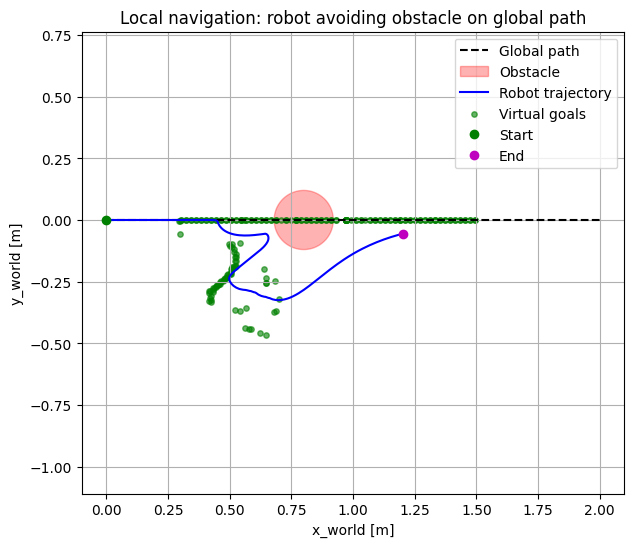

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ------------------------------------------------------------
# 1) LocalNavConfig + helpers
# ------------------------------------------------------------

@dataclass
class LocalNavConfig:
    max_lookahead_points: int = 30
    lookahead_dist_m: float   = 0.3    # how far along global path for LA
    occ_threshold: float      = 0.5    # occupancy above this = obstacle
    rep_influence_radius: float = 0.3  # [m] repulsion radius
    k_rep: float              = 0.8    # repulsive gain how strongly obstacles repel
    k_att: float              = 1.0    # attractive gain how strongly robot is attracted to path
    virt_goal_dist_m: float   = 0.15   # [m] distance of virtual goal in robot frame

def wrap_to_pi(angle): # wrap angle to [-pi, pi]
    return (angle + np.pi) % (2*np.pi) - np.pi

def go_to_goal_controller(pose, goal, Kv=0.65, Komega=3.0, v_max=0.25):
    """
    Simple go-to-goal controller in WORLD frame.
    pose  = [x, y, theta]
    goal  = [gx, gy]
    returns (v, omega)
    """
    x, y, theta = pose
    gx, gy = goal

    dx = gx - x
    dy = gy - y

    dist   = math.sqrt(dx*dx + dy*dy)
    angle  = math.atan2(dy, dx)
    err_th = wrap_to_pi(angle - theta)

    v      = Kv * dist
    v      = max(min(v, v_max), 0.0)   # no backward motion, capped speed
    omega  = Komega * err_th

    return v, omega

def integrate_unicycle(pose, v, omega, dt): # integrate unicycle model
    """
    Unicycle model integration in WORLD frame.
    pose = [x, y, theta]
    """
    x, y, theta = pose
    x     += v * math.cos(theta) * dt
    y     += v * math.sin(theta) * dt
    theta += omega * dt
    theta  = wrap_to_pi(theta)
    return np.array([x, y, theta])

# ------------------------------------------------------------
# 2) Build grid + LocalNavigator
#    (assumes LocalOccupancyGrid and LocalNavigator already exist)
# ------------------------------------------------------------

cfg  = LocalNavConfig()
grid = LocalOccupancyGrid(size_m=0.6, resolution_m=0.02)
navigator = LocalNavigator(grid, cfg)

# ------------------------------------------------------------
# 3) Global path + obstacle on the path (WORLD frame)
# ------------------------------------------------------------

# Global path: straight line along +x_world from x=0 to x=2 at y=0
xs = np.linspace(0.0, 2.0, 100)
ys = np.zeros_like(xs)
path = np.stack([xs, ys], axis=1)   # shape (100, 2)

# Static obstacle in WORLD frame, placed on the path
obst_world  = np.array([0.8, 0.0])   # 80 cm ahead on path
obst_radius = 0.12                   # obstacle "radius" in meters

# Robot starts at beginning of path, facing +x_world (theta=0)
pose = np.array([0.0, 0.0, 0.0])     # [x, y, theta]

# ------------------------------------------------------------
# 4) Simulation loop: use fake obstacle instead of real sensors
# ------------------------------------------------------------

dt        = 0.05      # 50 ms time step
n_steps   = 200       # number of control steps
poses     = [pose.copy()]
virt_goals = []


for k in range(n_steps):
    # ---- 4.1 Reset occupancy grid ----
    grid.grid[:, :] = 0.0

    # ---- 4.2 Paint the obstacle into the LOCAL grid ----
    # Approximate the obstacle as a ring of occupied points
    for angle in np.linspace(0.0, 2.0 * np.pi, 12, endpoint=False):
        px = obst_world[0] + obst_radius * math.cos(angle)
        py = obst_world[1] + obst_radius * math.sin(angle)

        # Express this obstacle point in ROBOT frame
        p_obs_robot = LocalNavigator.world_to_robot(pose, np.array([px, py]))
        x_m, y_m = float(p_obs_robot[0]), float(p_obs_robot[1])

        idx = grid._point_to_index(x_m, y_m)
        if idx is None:
            continue
        iy, ix = idx
        grid.grid[iy, ix] = 1.0   # mark as occupied

    # ---- 4.3 Local navigation: compute virtual goal in WORLD frame ----
    virt_world = navigator.compute_virtual_goal(pose, path)
    virt_goals.append(virt_world.copy() if virt_world is not None else None)

    if virt_world is None:
        # No valid goal: stop robot
        v, omega = 0.0, 0.0
    else:
        # ---- 4.4 Low-level control: go to virtual goal ----
        v, omega = go_to_goal_controller(pose, virt_world)

    # ---- 4.5 Update robot pose using unicycle model ----
    pose = integrate_unicycle(pose, v, omega, dt)
    poses.append(pose.copy())

# ------------------------------------------------------------
# 5) Visualization
# ------------------------------------------------------------

poses_arr = np.array(poses)

plt.figure(figsize=(7, 6))
plt.title("Local navigation: robot avoiding obstacle on global path")
plt.xlabel("x_world [m]")
plt.ylabel("y_world [m]")
plt.axis("equal")
plt.grid(True)

# Global path
plt.plot(path[:, 0], path[:, 1], 'k--', label="Global path")

# Obstacle (circle)
theta_c = np.linspace(0, 2*np.pi, 80)
cx = obst_world[0] + obst_radius * np.cos(theta_c)
cy = obst_world[1] + obst_radius * np.sin(theta_c)
plt.fill(cx, cy, alpha=0.3, color="red", label="Obstacle")

# Robot trajectory
plt.plot(poses_arr[:, 0], poses_arr[:, 1], 'b-', label="Robot trajectory")

# Virtual goals (optional, to see how they move)
vg_x = [vg[0] for vg in virt_goals if vg is not None]
vg_y = [vg[1] for vg in virt_goals if vg is not None]
plt.scatter(vg_x, vg_y, s=15, c="green", alpha=0.6, label="Virtual goals")

# Start and end markers
plt.plot(poses_arr[0, 0], poses_arr[0, 1], 'go', label="Start")
plt.plot(poses_arr[-1, 0], poses_arr[-1, 1], 'mo', label="End")

plt.legend()
plt.show()


In [ ]:
import time
import numpy as np

# ----------------- 1) SETUP (run once) -----------------

# 1.1 Local occupancy grid
grid = LocalOccupancyGrid(
    size_m=0.15,        # 15 cm x 15 cm
    resolution_m=0.001, # 1 mm cells (you can relax this later)
    hit_inc=0.1,
    decay=0.98
)

# 1.2 Local navigation config
cfg  = LocalNavConfig(
    lookahead_dist_m=0.15,
    max_lookahead_points=15,
    occ_threshold=0.5,
    rep_influence_radius=0.13,  # sensor max range (13 cm)
    k_att=1.0,
    k_rep=0.6,
    virt_goal_dist_m=0.10
)

# 1.3 LocalNavigator instance
local_nav = LocalNavigator(grid, cfg)

# 1.4 Go-to-goal controller
controller = GoToGoalController()

# 1.5 Global path in WORLD frame (meters) from your planner
# Example (you replace this with your visibility-graph output):
global_path = np.array([
    [0.0, 0.0],
    [0.3, 0.1],
    [0.6, 0.4],
    [0.9, 0.5],
])
data = [{'ground': [840, 916], 'sensor': [840, 916], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 912], 'sensor': [832, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 909], 'sensor': [831, 909], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 911], 'sensor': [831, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [829, 908], 'sensor': [829, 908], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 918], 'sensor': [831, 918], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 909], 'sensor': [832, 909], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 910], 'sensor': [831, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [830, 911], 'sensor': [830, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 912], 'sensor': [832, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 910], 'sensor': [832, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [830, 912], 'sensor': [830, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [836, 912], 'sensor': [836, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [840, 912], 'sensor': [840, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [836, 912], 'sensor': [836, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 919], 'sensor': [831, 919], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 912], 'sensor': [833, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [834, 919], 'sensor': [834, 919], 'left_speed': 0, 'right_speed': 0}, {'ground': [835, 912], 'sensor': [835, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [840, 912], 'sensor': [840, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 912], 'sensor': [833, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [834, 916], 'sensor': [834, 916], 'left_speed': 0, 'right_speed': 0}, {'ground': [839, 910], 'sensor': [839, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 910], 'sensor': [832, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [835, 911], 'sensor': [835, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [839, 916], 'sensor': [839, 916], 'left_speed': 0, 'right_speed': 0}, {'ground': [836, 912], 'sensor': [836, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 910], 'sensor': [833, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [840, 918], 'sensor': [840, 918], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 909], 'sensor': [832, 909], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 912], 'sensor': [833, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [840, 912], 'sensor': [840, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 912], 'sensor': [831, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 910], 'sensor': [832, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [834, 916], 'sensor': [834, 916], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 912], 'sensor': [833, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [836, 912], 'sensor': [836, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 914], 'sensor': [831, 914], 'left_speed': 0, 'right_speed': 0}, {'ground': [835, 911], 'sensor': [835, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 911], 'sensor': [831, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 912], 'sensor': [832, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [839, 909], 'sensor': [839, 909], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 912], 'sensor': [832, 912], 'left_speed': 27, 'right_speed': 25}, {'ground': [838, 912], 'sensor': [838, 912], 'left_speed': 37, 'right_speed': 37}, {'ground': [844, 923], 'sensor': [844, 923], 'left_speed': 44, 'right_speed': 45}, {'ground': [847, 918], 'sensor': [847, 918], 'left_speed': 46, 'right_speed': 41}, {'ground': [847, 918], 'sensor': [847, 918], 'left_speed': 46, 'right_speed': 41}, {'ground': [854, 918], 'sensor': [854, 918], 'left_speed': 52, 'right_speed': 47}, {'ground': [854, 918], 'sensor': [854, 918], 'left_speed': 51, 'right_speed': 47}, {'ground': [849, 920], 'sensor': [849, 920], 'left_speed': 51, 'right_speed': 47}, {'ground': [834, 919], 'sensor': [834, 919], 'left_speed': 49, 'right_speed': 50}, {'ground': [834, 919], 'sensor': [834, 919], 'left_speed': 49, 'right_speed': 50}, {'ground': [819, 896], 'sensor': [819, 896], 'left_speed': 49, 'right_speed': 52}, {'ground': [721, 738], 'sensor': [721, 738], 'left_speed': 50, 'right_speed': 53}, {'ground': [544, 490], 'sensor': [544, 490], 'left_speed': 52, 'right_speed': 54}, {'ground': [356, 262], 'sensor': [356, 262], 'left_speed': 52, 'right_speed': 54}, {'ground': [176, 128], 'sensor': [176, 128], 'left_speed': 51, 'right_speed': 54}, {'ground': [113, 115], 'sensor': [113, 115], 'left_speed': 51, 'right_speed': 53}, {'ground': [108, 113], 'sensor': [108, 113], 'left_speed': 50, 'right_speed': 52}, {'ground': [101, 111], 'sensor': [101, 111], 'left_speed': 50, 'right_speed': 51}, {'ground': [102, 109], 'sensor': [102, 109], 'left_speed': 49, 'right_speed': 45}, {'ground': [100, 110], 'sensor': [100, 110], 'left_speed': 48, 'right_speed': 50}, {'ground': [101, 119], 'sensor': [101, 119], 'left_speed': 50, 'right_speed': 51}, {'ground': [108, 113], 'sensor': [108, 113], 'left_speed': 50, 'right_speed': 49}, {'ground': [107, 113], 'sensor': [107, 113], 'left_speed': 50, 'right_speed': 49}, {'ground': [107, 116], 'sensor': [107, 116], 'left_speed': 50, 'right_speed': 45}, {'ground': [103, 122], 'sensor': [103, 122], 'left_speed': 50, 'right_speed': 44}, {'ground': [103, 124], 'sensor': [103, 124], 'left_speed': 47, 'right_speed': 44}, {'ground': [103, 119], 'sensor': [103, 119], 'left_speed': 47, 'right_speed': 45}, {'ground': [102, 124], 'sensor': [102, 124], 'left_speed': 48, 'right_speed': 45}, {'ground': [100, 121], 'sensor': [100, 121], 'left_speed': 49, 'right_speed': 45}, {'ground': [102, 112], 'sensor': [102, 112], 'left_speed': 48, 'right_speed': 45}, {'ground': [102, 111], 'sensor': [102, 111], 'left_speed': 50, 'right_speed': 46}, {'ground': [104, 113], 'sensor': [104, 113], 'left_speed': 48, 'right_speed': 46}, {'ground': [105, 112], 'sensor': [105, 112], 'left_speed': 48, 'right_speed': 47}, {'ground': [107, 121], 'sensor': [107, 121], 'left_speed': 50, 'right_speed': 48}, {'ground': [140, 209], 'sensor': [140, 209], 'left_speed': 50, 'right_speed': 50}, {'ground': [256, 382], 'sensor': [256, 382], 'left_speed': 52, 'right_speed': 56}, {'ground': [375, 486], 'sensor': [375, 486], 'left_speed': 54, 'right_speed': 56}, {'ground': [422, 462], 'sensor': [422, 462], 'left_speed': 54, 'right_speed': 59}, {'ground': [380, 325], 'sensor': [380, 325], 'left_speed': 54, 'right_speed': 55}, {'ground': [122, 116], 'sensor': [122, 116], 'left_speed': 54, 'right_speed': 53}, {'ground': [100, 112], 'sensor': [100, 112], 'left_speed': 53, 'right_speed': 52}, {'ground': [100, 110], 'sensor': [100, 110], 'left_speed': 51, 'right_speed': 53}, {'ground': [99, 113], 'sensor': [99, 113], 'left_speed': 48, 'right_speed': 51}, {'ground': [98, 116], 'sensor': [98, 116], 'left_speed': 47, 'right_speed': 48}, {'ground': [97, 117], 'sensor': [97, 117], 'left_speed': 48, 'right_speed': 48}, {'ground': [102, 108], 'sensor': [102, 108], 'left_speed': 48, 'right_speed': 45}, {'ground': [101, 108], 'sensor': [101, 108], 'left_speed': 47, 'right_speed': 43}, {'ground': [101, 105], 'sensor': [101, 105], 'left_speed': 46, 'right_speed': 43}, {'ground': [103, 109], 'sensor': [103, 109], 'left_speed': 46, 'right_speed': 43}, {'ground': [99, 107], 'sensor': [99, 107], 'left_speed': 46, 'right_speed': 45}, {'ground': [102, 108], 'sensor': [102, 108], 'left_speed': 47, 'right_speed': 46}, {'ground': [105, 107], 'sensor': [105, 107], 'left_speed': 48, 'right_speed': 49}, {'ground': [98, 106], 'sensor': [98, 106], 'left_speed': 49, 'right_speed': 48}, {'ground': [93, 101], 'sensor': [93, 101], 'left_speed': 48, 'right_speed': 49}, {'ground': [101, 106], 'sensor': [101, 106], 'left_speed': 52, 'right_speed': 49}, {'ground': [101, 107], 'sensor': [101, 107], 'left_speed': 52, 'right_speed': 51}, {'ground': [99, 111], 'sensor': [99, 111], 'left_speed': 53, 'right_speed': 52}, {'ground': [104, 110], 'sensor': [104, 110], 'left_speed': 52, 'right_speed': 55}, {'ground': [114, 161], 'sensor': [114, 161], 'left_speed': 53, 'right_speed': 56}, {'ground': [170, 295], 'sensor': [170, 295], 'left_speed': 54, 'right_speed': 55}, {'ground': [319, 468], 'sensor': [319, 468], 'left_speed': 53, 'right_speed': 54}, {'ground': [446, 570], 'sensor': [446, 570], 'left_speed': 51, 'right_speed': 51}, {'ground': [528, 592], 'sensor': [528, 592], 'left_speed': 50, 'right_speed': 49}, {'ground': [511, 496], 'sensor': [511, 496], 'left_speed': 49, 'right_speed': 48}, {'ground': [424, 420], 'sensor': [424, 420], 'left_speed': 49, 'right_speed': 45}, {'ground': [383, 404], 'sensor': [383, 404], 'left_speed': 47, 'right_speed': 44}, {'ground': [373, 406], 'sensor': [373, 406], 'left_speed': 46, 'right_speed': 42}, {'ground': [375, 407], 'sensor': [375, 407], 'left_speed': 46, 'right_speed': 43}, {'ground': [367, 408], 'sensor': [367, 408], 'left_speed': 46, 'right_speed': 43}, {'ground': [366, 411], 'sensor': [366, 411], 'left_speed': 47, 'right_speed': 44}, {'ground': [363, 412], 'sensor': [363, 412], 'left_speed': 48, 'right_speed': 48}, {'ground': [365, 412], 'sensor': [365, 412], 'left_speed': 49, 'right_speed': 50}, {'ground': [369, 415], 'sensor': [369, 415], 'left_speed': 50, 'right_speed': 51}, {'ground': [371, 415], 'sensor': [371, 415], 'left_speed': 52, 'right_speed': 52}, {'ground': [368, 416], 'sensor': [368, 416], 'left_speed': 52, 'right_speed': 56}, {'ground': [370, 414], 'sensor': [370, 414], 'left_speed': 53, 'right_speed': 57}, {'ground': [371, 411], 'sensor': [371, 411], 'left_speed': 56, 'right_speed': 56}, {'ground': [367, 410], 'sensor': [367, 410], 'left_speed': 56, 'right_speed': 57}, {'ground': [363, 414], 'sensor': [363, 414], 'left_speed': 51, 'right_speed': 51}, {'ground': [368, 411], 'sensor': [368, 411], 'left_speed': 51, 'right_speed': 51}, {'ground': [373, 411], 'sensor': [373, 411], 'left_speed': 49, 'right_speed': 49}, {'ground': [375, 416], 'sensor': [375, 416], 'left_speed': 48, 'right_speed': 47}, {'ground': [380, 426], 'sensor': [380, 426], 'left_speed': 48, 'right_speed': 45}, {'ground': [389, 473], 'sensor': [389, 473], 'left_speed': 46, 'right_speed': 44}, {'ground': [454, 578], 'sensor': [454, 578], 'left_speed': 45, 'right_speed': 43}, {'ground': [555, 656], 'sensor': [555, 656], 'left_speed': 46, 'right_speed': 43}, {'ground': [571, 550], 'sensor': [571, 550], 'left_speed': 44, 'right_speed': 43}, {'ground': [472, 449], 'sensor': [472, 449], 'left_speed': 45, 'right_speed': 43}, {'ground': [403, 420], 'sensor': [403, 420], 'left_speed': 44, 'right_speed': 42}, {'ground': [386, 418], 'sensor': [386, 418], 'left_speed': 46, 'right_speed': 48}, {'ground': [376, 416], 'sensor': [376, 416], 'left_speed': 47, 'right_speed': 48}, {'ground': [372, 413], 'sensor': [372, 413], 'left_speed': 48, 'right_speed': 48}, {'ground': [372, 413], 'sensor': [372, 413], 'left_speed': 49, 'right_speed': 48}, {'ground': [377, 416], 'sensor': [377, 416], 'left_speed': 49, 'right_speed': 50}, {'ground': [376, 417], 'sensor': [376, 417], 'left_speed': 52, 'right_speed': 50}, {'ground': [380, 416], 'sensor': [380, 416], 'left_speed': 51, 'right_speed': 52}, {'ground': [383, 422], 'sensor': [383, 422], 'left_speed': 51, 'right_speed': 54}, {'ground': [388, 418], 'sensor': [388, 418], 'left_speed': 53, 'right_speed': 57}, {'ground': [388, 421], 'sensor': [388, 421], 'left_speed': 53, 'right_speed': 56}, {'ground': [388, 427], 'sensor': [388, 427], 'left_speed': 52, 'right_speed': 57}, {'ground': [389, 428], 'sensor': [389, 428], 'left_speed': 53, 'right_speed': 56}, {'ground': [389, 427], 'sensor': [389, 427], 'left_speed': 53, 'right_speed': 57}, {'ground': [387, 421], 'sensor': [387, 421], 'left_speed': 53, 'right_speed': 57}, {'ground': [382, 413], 'sensor': [382, 413], 'left_speed': 54, 'right_speed': 57}, {'ground': [369, 405], 'sensor': [369, 405], 'left_speed': 52, 'right_speed': 50}, {'ground': [360, 399], 'sensor': [360, 399], 'left_speed': 51, 'right_speed': 46}, {'ground': [349, 398], 'sensor': [349, 398], 'left_speed': 48, 'right_speed': 44}, {'ground': [359, 452], 'sensor': [359, 452], 'left_speed': 47, 'right_speed': 43}, {'ground': [422, 548], 'sensor': [422, 548], 'left_speed': 44, 'right_speed': 43}, {'ground': [422, 548], 'sensor': [422, 548], 'left_speed': 44, 'right_speed': 43}, {'ground': [516, 587], 'sensor': [516, 587], 'left_speed': 45, 'right_speed': 44}, {'ground': [511, 475], 'sensor': [511, 475], 'left_speed': 43, 'right_speed': 43}, {'ground': [389, 289], 'sensor': [389, 289], 'left_speed': 44, 'right_speed': 43}, {'ground': [224, 150], 'sensor': [224, 150], 'left_speed': 45, 'right_speed': 44}, {'ground': [131, 120], 'sensor': [131, 120], 'left_speed': 47, 'right_speed': 44}, {'ground': [112, 115], 'sensor': [112, 115], 'left_speed': 49, 'right_speed': 46}, {'ground': [97, 108], 'sensor': [97, 108], 'left_speed': 49, 'right_speed': 49}, {'ground': [97, 109], 'sensor': [97, 109], 'left_speed': 52, 'right_speed': 52}, {'ground': [95, 112], 'sensor': [95, 112], 'left_speed': 51, 'right_speed': 54}, {'ground': [96, 116], 'sensor': [96, 116], 'left_speed': 54, 'right_speed': 56}, {'ground': [97, 121], 'sensor': [97, 121], 'left_speed': 53, 'right_speed': 56}, {'ground': [99, 126], 'sensor': [99, 126], 'left_speed': 54, 'right_speed': 56}, {'ground': [102, 123], 'sensor': [102, 123], 'left_speed': 53, 'right_speed': 53}, {'ground': [103, 122], 'sensor': [103, 122], 'left_speed': 51, 'right_speed': 52}, {'ground': [103, 122], 'sensor': [103, 122], 'left_speed': 49, 'right_speed': 49}, {'ground': [103, 128], 'sensor': [103, 128], 'left_speed': 48, 'right_speed': 47}, {'ground': [106, 128], 'sensor': [106, 128], 'left_speed': 49, 'right_speed': 45}, {'ground': [103, 126], 'sensor': [103, 126], 'left_speed': 46, 'right_speed': 44}, {'ground': [99, 127], 'sensor': [99, 127], 'left_speed': 46, 'right_speed': 43}, {'ground': [97, 118], 'sensor': [97, 118], 'left_speed': 45, 'right_speed': 43}, {'ground': [100, 120], 'sensor': [100, 120], 'left_speed': 48, 'right_speed': 47}, {'ground': [95, 119], 'sensor': [95, 119], 'left_speed': 50, 'right_speed': 51}, {'ground': [90, 120], 'sensor': [90, 120], 'left_speed': 51, 'right_speed': 52}, {'ground': [94, 134], 'sensor': [94, 134], 'left_speed': 54, 'right_speed': 53}, {'ground': [123, 244], 'sensor': [123, 244], 'left_speed': 54, 'right_speed': 57}, {'ground': [267, 425], 'sensor': [267, 425], 'left_speed': 55, 'right_speed': 56}, {'ground': [428, 503], 'sensor': [428, 503], 'left_speed': 53, 'right_speed': 56}, {'ground': [469, 455], 'sensor': [469, 455], 'left_speed': 52, 'right_speed': 57}, {'ground': [384, 286], 'sensor': [384, 286], 'left_speed': 51, 'right_speed': 55}, {'ground': [228, 145], 'sensor': [228, 145], 'left_speed': 51, 'right_speed': 53}, {'ground': [126, 114], 'sensor': [126, 114], 'left_speed': 48, 'right_speed': 49}, {'ground': [96, 114], 'sensor': [96, 114], 'left_speed': 48, 'right_speed': 47}, {'ground': [104, 108], 'sensor': [104, 108], 'left_speed': 48, 'right_speed': 46}, {'ground': [108, 111], 'sensor': [108, 111], 'left_speed': 45, 'right_speed': 45}, {'ground': [104, 117], 'sensor': [104, 117], 'left_speed': 44, 'right_speed': 45}, {'ground': [106, 115], 'sensor': [106, 115], 'left_speed': 45, 'right_speed': 42}, {'ground': [110, 126], 'sensor': [110, 126], 'left_speed': 46, 'right_speed': 42}, {'ground': [107, 118], 'sensor': [107, 118], 'left_speed': 45, 'right_speed': 43}, {'ground': [103, 112], 'sensor': [103, 112], 'left_speed': 45, 'right_speed': 45}, {'ground': [107, 111], 'sensor': [107, 111], 'left_speed': 46, 'right_speed': 49}, {'ground': [104, 111], 'sensor': [104, 111], 'left_speed': 48, 'right_speed': 50}, {'ground': [101, 112], 'sensor': [101, 112], 'left_speed': 50, 'right_speed': 52}, {'ground': [99, 114], 'sensor': [99, 114], 'left_speed': 51, 'right_speed': 50}, {'ground': [98, 111], 'sensor': [98, 111], 'left_speed': 53, 'right_speed': 57}, {'ground': [99, 109], 'sensor': [99, 109], 'left_speed': 54, 'right_speed': 57}, {'ground': [97, 106], 'sensor': [97, 106], 'left_speed': 53, 'right_speed': 56}, {'ground': [98, 113], 'sensor': [98, 113], 'left_speed': 53, 'right_speed': 57}, {'ground': [107, 114], 'sensor': [107, 114], 'left_speed': 53, 'right_speed': 57}, {'ground': [111, 177], 'sensor': [111, 177], 'left_speed': 52, 'right_speed': 57}, {'ground': [185, 324], 'sensor': [185, 324], 'left_speed': 53, 'right_speed': 56}, {'ground': [342, 459], 'sensor': [342, 459], 'left_speed': 52, 'right_speed': 53}, {'ground': [430, 470], 'sensor': [430, 470], 'left_speed': 49, 'right_speed': 53}, {'ground': [432, 368], 'sensor': [432, 368], 'left_speed': 48, 'right_speed': 52}, {'ground': [313, 193], 'sensor': [313, 193], 'left_speed': 49, 'right_speed': 48}, {'ground': [156, 112], 'sensor': [156, 112], 'left_speed': 48, 'right_speed': 45}, {'ground': [105, 109], 'sensor': [105, 109], 'left_speed': 48, 'right_speed': 45}, {'ground': [101, 112], 'sensor': [101, 112], 'left_speed': 48, 'right_speed': 42}, {'ground': [102, 116], 'sensor': [102, 116], 'left_speed': 47, 'right_speed': 43}, {'ground': [98, 114], 'sensor': [98, 114], 'left_speed': 47, 'right_speed': 43}, {'ground': [98, 116], 'sensor': [98, 116], 'left_speed': 47, 'right_speed': 43}, {'ground': [100, 121], 'sensor': [100, 121], 'left_speed': 47, 'right_speed': 44}, {'ground': [102, 121], 'sensor': [102, 121], 'left_speed': 47, 'right_speed': 47}, {'ground': [100, 115], 'sensor': [100, 115], 'left_speed': 50, 'right_speed': 51}, {'ground': [99, 114], 'sensor': [99, 114], 'left_speed': 53, 'right_speed': 53}, {'ground': [101, 113], 'sensor': [101, 113], 'left_speed': 54, 'right_speed': 53}, {'ground': [95, 112], 'sensor': [95, 112], 'left_speed': 55, 'right_speed': 53}, {'ground': [100, 112], 'sensor': [100, 112], 'left_speed': 53, 'right_speed': 52}, {'ground': [100, 109], 'sensor': [100, 109], 'left_speed': 52, 'right_speed': 52}, {'ground': [98, 115], 'sensor': [98, 115], 'left_speed': 51, 'right_speed': 51}, {'ground': [97, 116], 'sensor': [97, 116], 'left_speed': 52, 'right_speed': 51}, {'ground': [98, 106], 'sensor': [98, 106], 'left_speed': 51, 'right_speed': 55}, {'ground': [92, 101], 'sensor': [92, 101], 'left_speed': 54, 'right_speed': 58}, {'ground': [90, 111], 'sensor': [90, 111], 'left_speed': 53, 'right_speed': 56}, {'ground': [93, 145], 'sensor': [93, 145], 'left_speed': 52, 'right_speed': 56}, {'ground': [125, 251], 'sensor': [125, 251], 'left_speed': 50, 'right_speed': 49}, {'ground': [249, 436], 'sensor': [249, 436], 'left_speed': 49, 'right_speed': 45}, {'ground': [411, 544], 'sensor': [411, 544], 'left_speed': 50, 'right_speed': 45}, {'ground': [516, 581], 'sensor': [516, 581], 'left_speed': 48, 'right_speed': 45}, {'ground': [527, 497], 'sensor': [527, 497], 'left_speed': 49, 'right_speed': 44}, {'ground': [441, 412], 'sensor': [441, 412], 'left_speed': 47, 'right_speed': 41}, {'ground': [361, 389], 'sensor': [361, 389], 'left_speed': 47, 'right_speed': 44}, {'ground': [358, 391], 'sensor': [358, 391], 'left_speed': 48, 'right_speed': 43}, {'ground': [353, 392], 'sensor': [353, 392], 'left_speed': 49, 'right_speed': 43}, {'ground': [352, 388], 'sensor': [352, 388], 'left_speed': 48, 'right_speed': 45}, {'ground': [358, 385], 'sensor': [358, 385], 'left_speed': 48, 'right_speed': 47}, {'ground': [356, 384], 'sensor': [356, 384], 'left_speed': 49, 'right_speed': 48}, {'ground': [354, 386], 'sensor': [354, 386], 'left_speed': 49, 'right_speed': 51}, {'ground': [350, 388], 'sensor': [350, 388], 'left_speed': 50, 'right_speed': 53}, {'ground': [351, 386], 'sensor': [351, 386], 'left_speed': 50, 'right_speed': 55}, {'ground': [351, 388], 'sensor': [351, 388], 'left_speed': 52, 'right_speed': 53}, {'ground': [352, 391], 'sensor': [352, 391], 'left_speed': 52, 'right_speed': 50}, {'ground': [352, 391], 'sensor': [352, 391], 'left_speed': 52, 'right_speed': 50}, {'ground': [348, 391], 'sensor': [348, 391], 'left_speed': 49, 'right_speed': 43}, {'ground': [351, 391], 'sensor': [351, 391], 'left_speed': 45, 'right_speed': 43}, {'ground': [352, 391], 'sensor': [352, 391], 'left_speed': 45, 'right_speed': 43}, {'ground': [358, 398], 'sensor': [358, 398], 'left_speed': 45, 'right_speed': 44}, {'ground': [363, 400], 'sensor': [363, 400], 'left_speed': 48, 'right_speed': 48}, {'ground': [367, 407], 'sensor': [367, 407], 'left_speed': 49, 'right_speed': 52}, {'ground': [373, 442], 'sensor': [373, 442], 'left_speed': 52, 'right_speed': 52}, {'ground': [412, 531], 'sensor': [412, 531], 'left_speed': 52, 'right_speed': 57}, {'ground': [511, 675], 'sensor': [511, 675], 'left_speed': 53, 'right_speed': 57}, {'ground': [630, 804], 'sensor': [630, 804], 'left_speed': 54, 'right_speed': 59}, {'ground': [743, 886], 'sensor': [743, 886], 'left_speed': 52, 'right_speed': 57}, {'ground': [743, 886], 'sensor': [743, 886], 'left_speed': 52, 'right_speed': 57}, {'ground': [808, 898], 'sensor': [808, 898], 'left_speed': 53, 'right_speed': 52}, {'ground': [824, 896], 'sensor': [824, 896], 'left_speed': 51, 'right_speed': 50}, {'ground': [825, 900], 'sensor': [825, 900], 'left_speed': 48, 'right_speed': 46}, {'ground': [830, 898], 'sensor': [830, 898], 'left_speed': 44, 'right_speed': 45}, {'ground': [823, 892], 'sensor': [823, 892], 'left_speed': 46, 'right_speed': 43}, {'ground': [808, 848], 'sensor': [808, 848], 'left_speed': 45, 'right_speed': 42}, {'ground': [741, 777], 'sensor': [741, 777], 'left_speed': 44, 'right_speed': 43}, {'ground': [720, 760], 'sensor': [720, 760], 'left_speed': 45, 'right_speed': 44}, {'ground': [708, 760], 'sensor': [708, 760], 'left_speed': 46, 'right_speed': 45}, {'ground': [712, 752], 'sensor': [712, 752], 'left_speed': 48, 'right_speed': 47}, {'ground': [707, 754], 'sensor': [707, 754], 'left_speed': 49, 'right_speed': 51}, {'ground': [711, 754], 'sensor': [711, 754], 'left_speed': 50, 'right_speed': 53}, {'ground': [711, 769], 'sensor': [711, 769], 'left_speed': 55, 'right_speed': 55}, {'ground': [711, 769], 'sensor': [711, 769], 'left_speed': 55, 'right_speed': 55}, {'ground': [715, 789], 'sensor': [715, 789], 'left_speed': 55, 'right_speed': 50}, {'ground': [712, 794], 'sensor': [712, 794], 'left_speed': 54, 'right_speed': 51}, {'ground': [719, 797], 'sensor': [719, 797], 'left_speed': 54, 'right_speed': 48}, {'ground': [719, 799], 'sensor': [719, 799], 'left_speed': 52, 'right_speed': 48}, {'ground': [732, 792], 'sensor': [732, 792], 'left_speed': 46, 'right_speed': 47}, {'ground': [734, 792], 'sensor': [734, 792], 'left_speed': 44, 'right_speed': 47}, {'ground': [733, 785], 'sensor': [733, 785], 'left_speed': 45, 'right_speed': 48}, {'ground': [730, 781], 'sensor': [730, 781], 'left_speed': 51, 'right_speed': 53}, {'ground': [726, 790], 'sensor': [726, 790], 'left_speed': 56, 'right_speed': 54}, {'ground': [728, 786], 'sensor': [728, 786], 'left_speed': 54, 'right_speed': 53}, {'ground': [723, 786], 'sensor': [723, 786], 'left_speed': 52, 'right_speed': 51}, {'ground': [726, 787], 'sensor': [726, 787], 'left_speed': 50, 'right_speed': 48}]

# 1.6 EKF + Thymio client are created elsewhere, e.g.
# ekf = YourEKF(...)
# thymio = YourThymioClient(...)
lambda_ = 0.39735099337748336  # conversion factor
d = 93.5         # distance between wheels
# Default value for now
Q = np.diag([0.03, 0.03, 0.03])
R = np.diag([0.01, 0.01, 0.01])

system = DifferentialDriveSystem(dt, lambda_, d, Q, R)
    
# Initial state and covariance
mu0 = np.array([0, 0, 0])
Sigma0 = 1000 * np.eye(3)

ekf = ExtendedKalmanFilter(
    mu0, Sigma0,
    system
)

# To store estimates
x_est = []
P_est = []

# 1.7 Initial command (for EKF prediction)
last_cmd = (0, 0)   # (uL, uR) from previous step; initially stopped

# 1.8 Control loop timing
dt = 0.1            # 100 ms per control step
MAX_STEPS = len(data)    # safety limit


# ----------------- 2) MAIN CONTROL LOOP -----------------

for step in range(MAX_STEPS):

    # ---------- 2.1 EKF PREDICTION (friend) ----------
    # Uses previous control command (last_cmd) to predict new state.
    # last_cmd is in motor units (uL, uR).
    current_data = data[step]

    u = np.array([current_data["left_speed"], current_data["right_speed"]])

    new_x_est, new_P_est = ekf.predict(u) # Only prediction step because no measurements are available (no camera)

    # ---------- 2.2 EKF UPDATE (friend) ----------
    # Friend reads whatever sensors the EKF needs (not your prox!),     
    # e.g. wheel encoders or ground sensors.
    if k % 10 == 0: # Simulate a measurement every 10 time steps
        z = new_x_est + np.random.multivariate_normal(np.zeros(3), R)
        new_x_est, new_P_est = ekf.update(z)
    x_est.append(new_x_est)
    P_est.append(new_P_est)
    # Get current pose estimate in WORLD frame [m, m, rad]
    pose = new_x_est          # e.g. returns np.array([x, y, theta])

    # ---------- 2.3 UPDATE OCCUPANCY GRID (you) ----------
    # Read Thymio horizontal proximity sensors (for local obstacle map).
    sensor_vals = thymio.get_prox_horiz()   # 7-values array/list
    grid.update_from_sensor_vals(sensor_vals)

    # ---------- 2.4 LOCAL NAVIGATION: virtual goal (you) ----------
    virt_goal = local_nav.compute_virtual_goal(pose, global_path)
    # virt_goal is [xg, yg] in WORLD frame (meters)

    if virt_goal is None:
        # No path / no valid virtual goal → stop robot
        thymio.set_motors(0, 0)
        print("No virtual goal; stopping at step", step)
        break

    # ---------- 2.5 CONTROLLER: motor commands (you) ----------
    # INPUTS to controller:
    #   - pose      : [x, y, theta] (WORLD frame)
    #   - virt_goal : [xg, yg] (WORLD frame)
    uL, uR, info = controller.compute_motor_commands(pose, virt_goal)

    # info contains debugging values such as:
    #   info["rho"]   : distance to virtual goal
    #   info["alpha"] : heading error
    #   info["stopped"]: True if within tol and stopped

    # ---------- 2.6 SEND COMMAND & SAVE IT ----------
    thymio.set_motors(uL, uR)   # OUTPUT: goes directly to Thymio
    last_cmd = (uL, uR)         # EKF will use this in next iteration

    # ---------- 2.7 LOOP TIMING ----------
    time.sleep(dt)


NameError: name 'ekf' is not defined

In [ ]:
from tdmclient import ClientAsync
client = ClientAsync()
node = await client.wait_for_node()
await node.lock()

test_functions = True

In [ ]:
await node.wait_for_variables()
node.var

In [ ]:
async def print_sensor_values(sensor_id, print_range=10, delta_time=0.2):
    """
    Print the sensor value sensor_id print_range times, every delta_time seconds
    """
    await node.wait_for_variables({str(sensor_id)})
    for i in range(print_range):
        print(list(node[sensor_id]))
        await client.sleep(delta_time)
        
#await print_sensor_values('prox.ground.reflected')

In [ ]:
#motor function
def motors(l_speed=500, r_speed=500, verbose=False):
    """
    Sets the motor speeds of the Thymio 
    param l_speed: left motor speed
    param r_speed: right motor speed
    param verbose: whether to print status messages or not
    """
    # Printing the speeds if requested
    if verbose:
        print("\t\t Setting speed : ", l_speed, r_speed)
    return {
        "motor.left.target": [l_speed],
        "motor.right.target": [r_speed],
    }
if test_functions:
    await node.set_variables(motors(100.1, 100)) #test with lower speed value
    await client.sleep(2)
    await node.set_variables(motors(0, 0))
 

In [ ]:
await tdmclient.notebook.stop()